In [1]:
import h5py
import xarray as xr
import imageio
import matplotlib.pyplot as plt
import os
import numpy as np
import tidy3d as td
import matplotlib
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from scipy.fft import fftn, ifftn, fftshift
from scipy.interpolate import interp1d
from scipy.signal import argrelextrema
import sys
import scipy
from scipy.ndimage import gaussian_filter1d
# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

tidy3dAPI = os.environ["API_TIDY3D_KEY"]
plt.rc('font', family='Arial')

In [2]:
data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90.h5")

In [3]:
data.keys()

dict_keys(['2.90'])

In [4]:
a=2.562629142772549

In [ ]:
def diameter(intensity_array,x,y):
    intensity = intensity_array
    integral_1 = scipy.integrate.simpson(scipy.integrate.simpson(intensity**2, x=y, axis=1), x=x, axis=0)
    integral_2 = scipy.integrate.simpson(scipy.integrate.simpson(intensity, x=y, axis=1), x=x, axis=0)**2
    
    return 2*np.sqrt((integral_2/integral_1)/np.pi)


def moving_average(x, w=3):
    if w <= 1:
        return x
    return np.convolve(x, np.ones(w), 'valid') / w

C:\Users\HernandF\AppData\Local\Temp\ipykernel_52156\2897269542.py:6: RuntimeWarning: divide by zero encountered in divide
  return 2*np.sqrt((integral_2/integral_1)/np.pi)


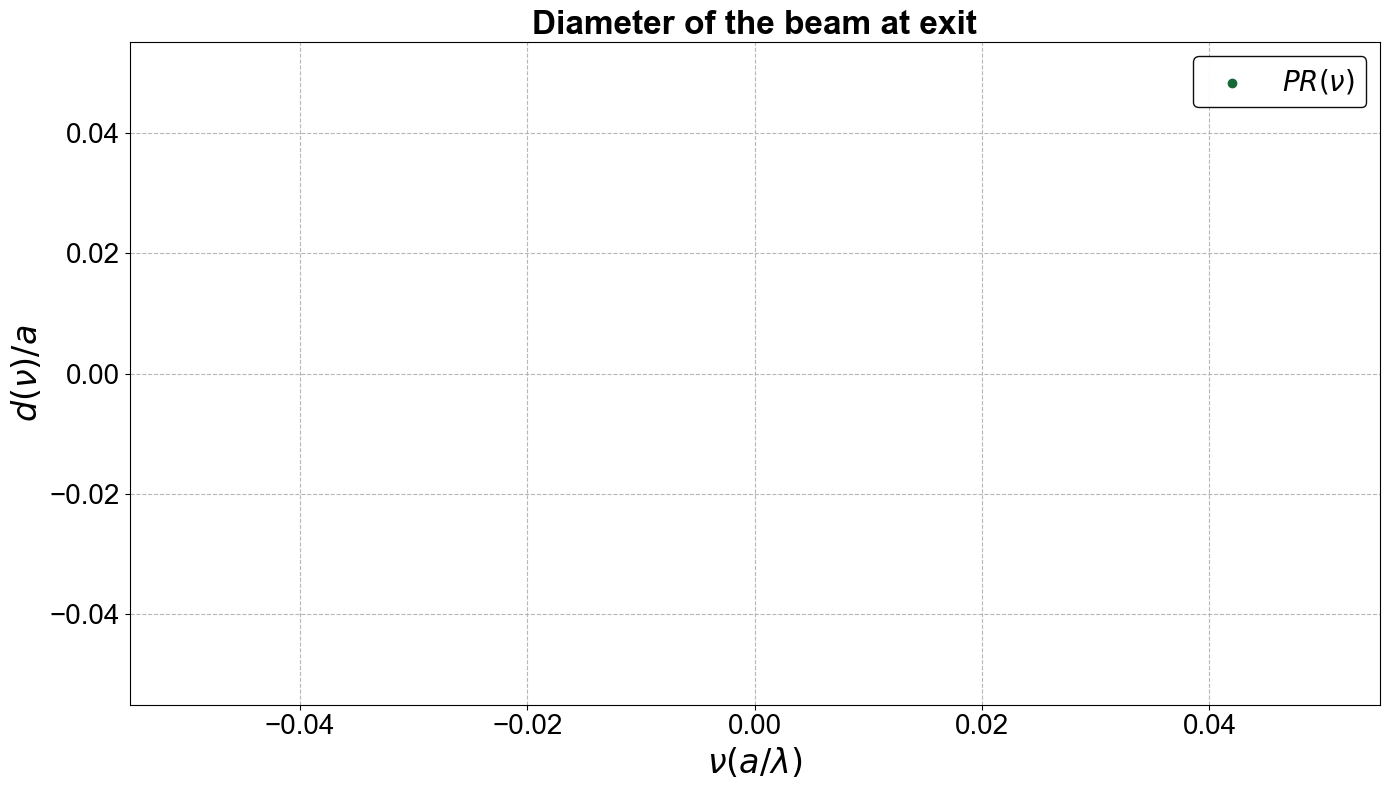

In [ ]:
from scipy.optimize import curve_fit
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

for k,key in enumerate(data.keys()):
    intensity_values = (np.abs(data[key]["Ex"])**2 + np.abs(data[key]["Ey"])**2 + np.abs(data[key]["Ez"])**2).squeeze()
    # intensity_values[intensity_values/np.max(intensity_values)<=1e-12]=0

    d = diameter(intensity_values,data[key]["x"],data[key]["y"])/a
    spread_smooth_nan_mask = ~np.isnan(d)
    freq = a*data[key]["f"]/td.C_0
    ax.scatter(freq,d/a,label=rf"$d(\nu)/a$")
    

ax.set_xlabel(rf"$\nu (a/\lambda)$", fontsize=24, fontweight='bold')
ax.set_ylabel(rf"$d(\nu)/a$", fontsize=24, fontweight='bold')
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=20, framealpha=0.95, edgecolor='black')


# ax.set_xlim(0,17.5)
# ax.set_ylim(0,40)
# Improve tick label size
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title(rf"Diameter of the beam at exit", fontsize=24, fontweight='bold')

# Add subtle background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()
